In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F

In [2]:
import os
import random
import numpy as np
import torch

def seed_everything(seed=42):
    # 1. Base Python and OS environment
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 2. NumPy library
    np.random.seed(seed)
    
    # 3. PyTorch CPU and CUDA global seeds
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # Safe for multi-GPU setups
    
    # 4. Force CuDNN to use deterministic algorithms (Crucial for CNNs)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # 5. Force PyTorch deterministic operations
    torch.use_deterministic_algorithms(True)

# Run this before building your model or dataloaders
seed_everything(42)


In [3]:
torch.multiprocessing.set_sharing_strategy('file_system') # Avoids weird memory leak issues later

In [4]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=3,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=3,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [5]:
# Inherit the base Neural net class to make the new Net class

class Net(nn.Module):
    # Initialize key properties of the neural network
    def __init__(self):
        super(Net, self).__init__()
        # Convolutional layer with 3 input channels and 6 output channels , 5 Defines the size of the sliding window
        self.conv1 = nn.Conv2d(3, 6, 5) # Input layer
        
        self.pool = nn.MaxPool2d(2, 2)
        # Pooling layer with a kernel size of 2*2 and stride of 2

        self.conv2 = nn.Conv2d(6, 16, 5) # Convolutional layer with 6 different channels
        # Takes 6 input channels, produces 16 output channels
        self.fc1 = nn.Linear(16 * 5 * 5, 120) # Applies a linear tranformation to incoming data
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10) # 10 -> The final number of classes
        # Output layer

    # Defines the direction of data flow from input to ouput
    # (Forward pass implementation)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # Input layer
        x = self.pool(F.relu(self.conv2(x))) # Hidden layer
        x = x.view(-1, 16 * 5 * 5) # Flattening is necessary because our dense layer expects 1-D data
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x) # Why are we not doing relu here
        return x

In [6]:
net = Net()

In [7]:
criterion = nn.CrossEntropyLoss() # Sparse Cross Entropy Loss
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [8]:
# Training Loop

import datetime

def run_training_loop(epochs):
    for epoch in range(epochs):
    
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data # Supervised learning because we work with labels
    
            optimizer.zero_grad() # Clear gradients before computing new ones
    
            # Use the model to make predictions -> Forward pass
            outputs = net(inputs)

            loss = criterion(outputs, labels) # Compute how wrong the predictions are
            loss.backward() # Backpropagation
            optimizer.step() # Update every trainable weight suing gradients computed by loss.backward()
    
            running_loss += loss.item()
            if i % 2000 == 1999:
                print('[%d, %5d] loss: %.3f' %
                      (epoch + 1, i + 1, running_loss / 2000))
                running_loss = 0.0
    
    print(f'Finished Training. Loss {loss}')

In [9]:
run_training_loop(2)

[1,  2000] loss: 2.177
[1,  4000] loss: 1.824
[1,  6000] loss: 1.683
[1,  8000] loss: 1.615
[1, 10000] loss: 1.536
[1, 12000] loss: 1.513
[1, 14000] loss: 1.483
[1, 16000] loss: 1.430
[2,  2000] loss: 1.367
[2,  4000] loss: 1.365
[2,  6000] loss: 1.349
[2,  8000] loss: 1.308
[2, 10000] loss: 1.310
[2, 12000] loss: 1.309
[2, 14000] loss: 1.291
[2, 16000] loss: 1.262
Finished Training. Loss 1.8206514120101929


In [10]:
correct = 0
total = 0
incorrect_preds = {"image": [], "label": [], "prediction": []}
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)

        correct += (predicted == labels).sum().item()
        
        for i,p in enumerate(predicted):
            if p != labels[i]:
                # Incorrect label, add to incorrect list
                incorrect_preds["image"].append(images[i])
                incorrect_preds["label"].append(labels[i].item())
                incorrect_preds["prediction"].append(p.item())

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 54 %


In [11]:
# Export trained model for independent inference

from pathlib import Path

MODEL_DIR = Path("./models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "cifar10_net.pth"

model_artifact = {
    "model_state_dict": net.state_dict(),
    "classes": classes,
    "input_size": (32, 32),
    "normalize_mean": (0.5, 0.5, 0.5),
    "normalize_std": (0.5, 0.5, 0.5),
}

torch.save(model_artifact, MODEL_PATH)

print(f"Model exported to: {MODEL_PATH}")

Model exported to: models/cifar10_net.pth


In [12]:
import matplotlib.pyplot as plt


def display_image_from_tensor(tensor, l, p):
    fig, ax = plt.subplots()
    mean = std =  torch.tensor([0.5, 0.5, 0.5]).view(3,1,1) # De-normalizing

    img_np = tensor.cpu().detach() * std + mean
    img_np = img_np.numpy().transpose(1,2,0)
    img_np = img_np.clip(0, 1)

    ax.imshow(img_np, interpolation="bilinear")
    print(f"Label: {classes[l]}, Predicted: {classes[p]}")
    
    plt.axis('off')
    plt.show()
    return

In [13]:
import pandas as pd

In [14]:
label_map = {
    0: "plane", 1: "car", 2: "bird", 3:"cat",
    4: "deer", 5: "dog", 6: "frog", 7: "horse",
    8: "ship", 9: "truck"
}

In [15]:
incorrect_df = pd.DataFrame(incorrect_preds)


incorrect_df["label_name"] = incorrect_df["label"].map(label_map)
incorrect_df["prediction_name"] = incorrect_df["prediction"].map(label_map)

In [16]:
samples_df = incorrect_df[incorrect_df["label_name"] == "horse"]
# change bird with what you want to analyze

In [17]:
def analyze_sample(sample):
    # Takes a series object
    image = sample["image"]
    label = sample["label"]
    prediction = sample["prediction"]

    display_image_from_tensor(image, label, prediction)

    return

Label: horse, Predicted: ship


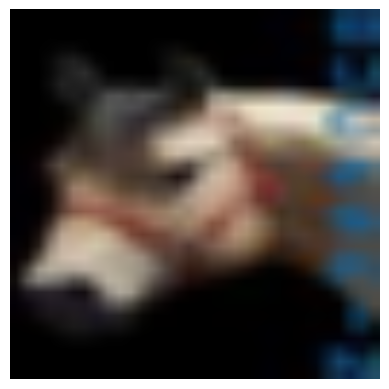

In [18]:
analyze_sample(samples_df.iloc[0]) # 32 * 32 px 

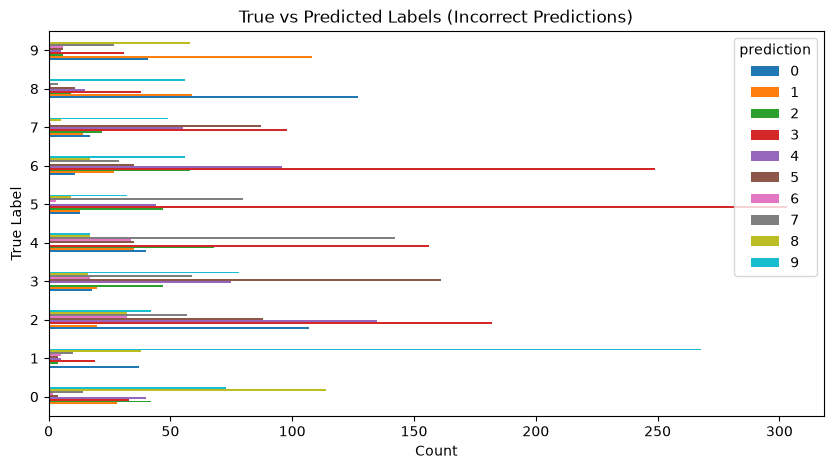

In [19]:
pd.crosstab(
    incorrect_df["label"],
    incorrect_df["prediction"]
).plot.barh(figsize=(10, 5))

plt.xlabel("Count")
plt.ylabel("True Label")
plt.title("True vs Predicted Labels (Incorrect Predictions)")
plt.show()

In [20]:
incorrect_df.keys()

Index(['image', 'label', 'prediction', 'label_name', 'prediction_name'], dtype='str')

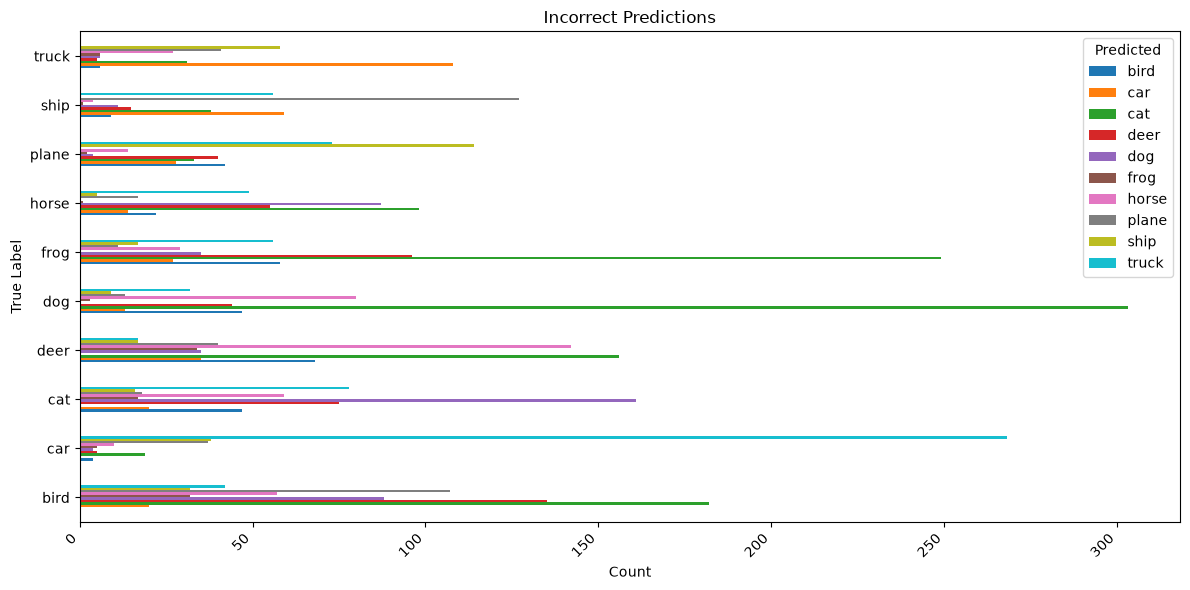

In [21]:
pd.crosstab(
    incorrect_df["label_name"],
    incorrect_df["prediction_name"]
).plot.barh(figsize=(12, 6))

plt.xlabel("Count")
plt.ylabel("True Label")
plt.title("Incorrect Predictions")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Predicted")
plt.tight_layout()
plt.show()

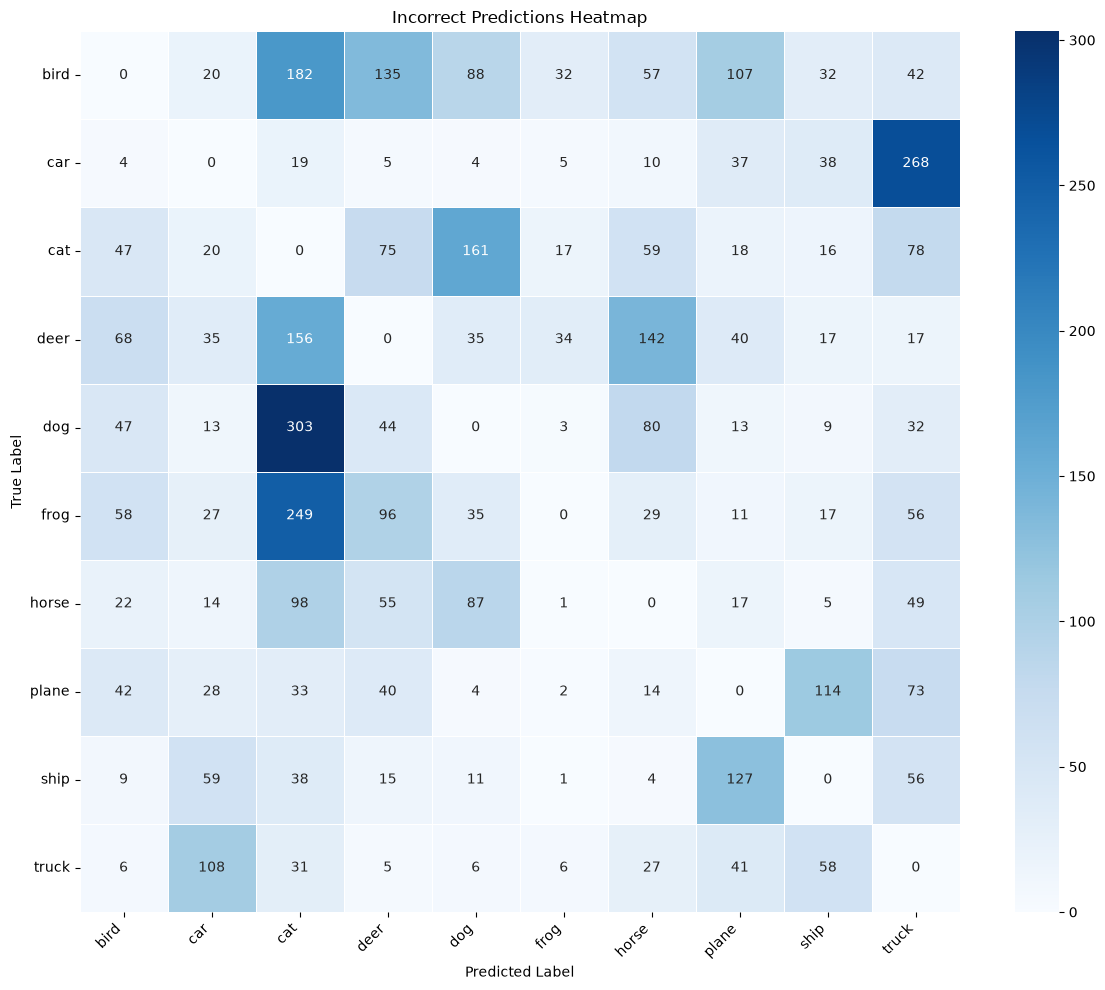

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Build confusion table
conf = pd.crosstab(
    incorrect_df["label_name"],
    incorrect_df["prediction_name"]
)

# Optional: keep labels in alphabetical order
conf = conf.sort_index().sort_index(axis=1)

# Plot
plt.figure(figsize=(12, 10))

sns.heatmap(
    conf,
    annot=True,      # Show counts
    fmt="d",         # Integer format
    cmap="Blues",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Incorrect Predictions Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [23]:
# Inference on smartphone images
#
# Place validation images in:
#     data/validation/
#
# The trained CIFAR-10 model expects 32x32 RGB images using
# the same normalization as the training data.

from pathlib import Path
from PIL import Image
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt


validation_dir = Path("./data/validation")

inference_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

validation_images = sorted(
    path for path in validation_dir.iterdir()
    if path.suffix.lower() in image_extensions
)

net.eval()

results = []

with torch.no_grad():
    for image_path in validation_images:
        image = Image.open(image_path).convert("RGB")
        image_tensor = inference_transform(image).unsqueeze(0)

        outputs = net(image_tensor)

        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, dim=1)

        results.append({
            "image": image_path.name,
            "prediction": classes[predicted.item()],
            "confidence": confidence.item()
        })


inference_df = pd.DataFrame(results)

if not inference_df.empty:
    inference_df["confidence"] = (
        inference_df["confidence"] * 100
    ).round(2)

display(inference_df)

,image,prediction,confidence
0,bike1.jpg,cat,20.87
1,bird1.jpg,deer,36.57
2,bird2.jpg,cat,26.05
3,car1.jpg,car,70.50
4,car2.jpg,car,39.45
5,car3.jpg,car,84.88
6,cat1.jpg,deer,60.81
7,cat2.jpg,truck,17.96
8,cat3.jpg,deer,25.73
9,cat4.jpg,horse,23.44
